# 📊Student Learning Analytics📊
**A practical application of the data-analysis skills developed through PCAD certification.**

Explore study-time categories, school absences and final grades📁

 رح ندرس العلاقات الموجودة ف البيانات، مع التفريق بين الارتباط والسببيه، ومراجعة حجم كل مجموعة قبل افسير متوسطها 



In [1]:
# If needed in Colab, uncomment and run:
# %pip install numpy==2.3.5 pandas==2.2.3 matplotlib==3.10.8 scipy==1.17.0
from pathlib import Path
from IPython.display import display, Image
import sys
print('Python:', sys.version.split()[0])

Python: 3.12.14


## 1. Data source and questions
1. How are final grades and absences distributed?
2. How do final-grade averages vary across reported study-time categories?
3. Does separating the two schools change the picture?
4. How sensitive are selected correlations to recorded zero final grades?

Data attribution: (https://doi.org/10.24432/C5TG7T), (https://creativecommons.org/licenses/by/4.0/). 



In [2]:
DATA_PATH = Path('data/raw/student-por.csv')
if not DATA_PATH.exists():
    import urllib.request, zipfile, io
    url = 'https://archive.ics.uci.edu/static/public/320/student+performance.zip'
    archive = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url, timeout=30).read()))
    inner = zipfile.ZipFile(io.BytesIO(archive.read('student.zip')))
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    DATA_PATH.write_bytes(inner.read('student-por.csv'))
print('Input ready:', DATA_PATH)

Input ready: data/raw/student-por.csv


## 2. Reusable analysis functions


In [3]:
"""Reproducible exploratory analysis of the UCI Portuguese-course dataset."""
from pathlib import Path
import base64
import hashlib
import html
import json
import platform
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STUDY_LABELS = {1: "<2 hours", 2: "2–5 hours", 3: "5–10 hours", 4: ">10 hours"}
COLUMNS = ["school", "studytime", "absences", "G1", "G2", "G3"]
GREEN = "#176B58"
PURPLE = "#8270A6"


def load_and_validate(path):
    """Normalize format and reject invalid values; do not invent missingness."""
    raw = pd.read_csv(path, sep=";")
    raw.columns = raw.columns.str.strip()
    missing = set(COLUMNS) - set(raw.columns)
    if missing:
        raise ValueError(f"Required columns missing: {sorted(missing)}")
    data = raw[COLUMNS].copy()
    data["school"] = data["school"].astype("string").str.strip().str.upper()
    for column in COLUMNS[1:]:
        data[column] = pd.to_numeric(data[column], errors="raise")
    if data.empty or data.isna().any().any():
        raise ValueError("Empty data or missing values in selected columns: investigate before analysis")
    if not data.school.isin(["GP", "MS"]).all():
        raise ValueError("Unknown school category")
    if not data.studytime.isin(STUDY_LABELS).all():
        raise ValueError("studytime must use category codes 1–4")
    for column, low, high in [("absences", 0, 93), ("G1", 0, 20), ("G2", 0, 20), ("G3", 0, 20)]:
        if not data[column].between(low, high).all() or not (data[column] % 1 == 0).all():
            raise ValueError(f"Invalid integer or range in {column}")
    data[COLUMNS[1:]] = data[COLUMNS[1:]].astype(int)
    audit = {"rows": len(raw), "source_columns": len(raw.columns),
             "selected_columns": COLUMNS, "missing_cells_source": int(raw.isna().sum().sum()),
             "exact_duplicate_rows_source": int(raw.duplicated().sum()),
             "identical_selected_profiles": int(data.duplicated().sum()),
             "zero_final_grades": int(data.G3.eq(0).sum()),
             "rows_removed": 0, "values_imputed": 0,
             "policy": "Retain records with identical selected profiles: there is no unique student ID. Retain zero grades; do not assume missingness."}
    return data, audit


def bootstrap_mean(values, rng, repetitions=2000):
    """95% percentile interval under row-wise exchangeability, not population coverage."""
    values = np.asarray(values, dtype=float)
    if not len(values) or not np.isfinite(values).all() or repetitions < 100:
        raise ValueError("Need finite nonempty data and at least 100 repetitions")
    draws = rng.choice(values, size=(repetitions, len(values)), replace=True).mean(axis=1)
    return tuple(np.quantile(draws, [.025, .975]))


def summarize_groups(data, group_columns, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for key, group in data.groupby(group_columns, sort=True, observed=True):
        key = key if isinstance(key, tuple) else (key,)
        row = dict(zip(group_columns, key))
        low, high = bootstrap_mean(group.G3, rng)
        row.update(n=len(group), mean_grade=float(group.G3.mean()),
                   median_grade=float(group.G3.median()),
                   ci_low=float(low), ci_high=float(high))
        rows.append(row)
    return pd.DataFrame(rows)


def sql_summary(data, school=None):
    """Parameterized school filter; join a category lookup to demonstrate SQL."""
    lookup = pd.DataFrame({"studytime": list(STUDY_LABELS), "study_label": list(STUDY_LABELS.values())})
    query = """
    SELECT s.studytime, l.study_label, COUNT(*) AS n,
           AVG(s.G3) AS mean_grade, AVG(s.absences) AS mean_absences
    FROM students AS s
    INNER JOIN study_categories AS l ON s.studytime = l.studytime
    WHERE (? IS NULL OR s.school = ?)
    GROUP BY s.studytime, l.study_label
    HAVING COUNT(*) >= 1
    ORDER BY s.studytime
    """
    with sqlite3.connect(":memory:") as connection:
        data.to_sql("students", connection, index=False)
        lookup.to_sql("study_categories", connection, index=False)
        return pd.read_sql_query(query, connection, params=(school, school))


def run_analysis(input_path="data/raw/student-por.csv", output_dir="results", seed=42):
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    data, audit = load_and_validate(input_path)
    grouped = summarize_groups(data, ["studytime"], seed)
    stratified = summarize_groups(data, ["school", "studytime"], seed)
    corr = data[COLUMNS[1:]].corr(method="spearman")
    sql = sql_summary(data)
    np.testing.assert_allclose(sql.mean_grade, grouped.mean_grade)
    np.testing.assert_array_equal(sql.n, grouped.n)
    sensitivity = []
    for label, subset in [("All recorded grades", data), ("G3 > 0 sensitivity only", data[data.G3 > 0])]:
        sensitivity.append({"sample": label, "n": len(subset),
                            "studytime_G3_spearman": subset.studytime.corr(subset.G3, method="spearman"),
                            "absences_G3_spearman": subset.absences.corr(subset.G3, method="spearman")})
    sensitivity = pd.DataFrame(sensitivity)
    for filename, frame in [("selected_data.csv", data), ("studytime_summary.csv", grouped),
                             ("school_studytime_summary.csv", stratified),
                             ("sql_studytime_summary.csv", sql), ("sensitivity.csv", sensitivity),
                             ("descriptive_statistics.csv", data[COLUMNS[1:]].describe().reset_index())]:
        frame.to_csv(output / filename, index=False)
    corr.to_csv(output / "spearman_correlations.csv")
    (output / "quality_audit.json").write_text(json.dumps(audit, indent=2)+"\n")

    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.facecolor": "white"})
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
    axes[0].hist(data.G3, bins=np.arange(-.5, 21.5, 1), color=GREEN, edgecolor="white")
    axes[0].set(xlabel="Final grade (0–20)", ylabel="Records", title="Final-grade distribution", xlim=(-.5, 20.5))
    axes[1].hist(data.absences, bins=np.arange(-.5, data.absences.max()+1.5, 2), color=PURPLE, edgecolor="white")
    axes[1].set(xlabel="Recorded absences", ylabel="Records", title="Absences are unevenly distributed")
    fig.savefig(output / "distributions.png", dpi=160)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    x = np.arange(len(grouped))
    ax.errorbar(x, grouped.mean_grade,
                yerr=np.vstack([grouped.mean_grade-grouped.ci_low, grouped.ci_high-grouped.mean_grade]),
                fmt="o", color=GREEN, capsize=6, markersize=8, linewidth=2)
    for i, row in grouped.iterrows():
        ax.text(i, row.ci_high+.4, f"n={int(row.n)}", ha="center", color="#515E58")
    ax.set(xticks=x, xticklabels=[STUDY_LABELS[k] for k in grouped.studytime], ylim=(0, 20),
           xlabel="Reported weekly study-time category", ylabel="Mean final grade (0–20)",
           title="Study-time groups: compare averages and sample sizes")
    fig.text(.5, -.015, "Intervals: 95% row-bootstrap percentiles; descriptive, not causal.", ha="center", fontsize=9)
    fig.savefig(output / "studytime_grades.png", dpi=160, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for offset, (school, color) in zip([-.10, .10], [("GP", GREEN), ("MS", PURPLE)]):
        part = stratified[stratified.school == school]
        ax.errorbar(part.studytime-1+offset, part.mean_grade,
                    yerr=np.vstack([part.mean_grade-part.ci_low, part.ci_high-part.mean_grade]),
                    fmt="o", capsize=4, color=color, label=school)
        for row in part.itertuples():
            ax.text(row.studytime-1+offset, row.ci_high+.35, str(row.n), ha="center", fontsize=8, color=color)
    ax.set(xticks=range(4), xticklabels=list(STUDY_LABELS.values()), ylim=(0, 20),
           xlabel="Reported weekly study-time category", ylabel="Mean final grade (0–20)",
           title="Separate schools before interpreting the pooled pattern")
    ax.legend(title="School")
    fig.text(.5, -.015, "Labels show n; row-bootstrap intervals do not account for school clustering.", ha="center", fontsize=9)
    fig.savefig(output / "school_comparison.png", dpi=160, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
    plot = ax.imshow(corr, cmap="BrBG", vmin=-1, vmax=1)
    labels = ["Study time", "Absences", "G1", "G2", "G3"]
    ax.set(xticks=range(5), yticks=range(5), xticklabels=labels, yticklabels=labels,
           title="Spearman correlations: association, not causation")
    for i in range(5):
        for j in range(5):
            value = corr.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value)>.6 else "#193C34")
    fig.colorbar(plot, ax=ax, shrink=.8, label="Spearman ρ")
    fig.savefig(output / "correlations.png", dpi=160)
    plt.close(fig)

    summary = {"rows": len(data), "schools": int(data.school.nunique()),
               "mean_final_grade": float(data.G3.mean()), "median_final_grade": float(data.G3.median()),
               "studytime_grade_spearman": float(corr.loc["studytime", "G3"]),
               "absences_grade_spearman": float(corr.loc["absences", "G3"]),
               "prior_grade_G2_G3_spearman": float(corr.loc["G2", "G3"]),
               "seed": seed, "bootstrap_repetitions_per_group": 2000,
               "input_sha256": hashlib.sha256(Path(input_path).read_bytes()).hexdigest(),
               "python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__}
    (output / "summary.json").write_text(json.dumps(summary, indent=2)+"\n")
    write_report(output, summary, grouped, sensitivity, audit)
    return {"data": data, "audit": audit, "groups": grouped, "school_groups": stratified,
            "correlations": corr, "sql": sql, "sensitivity": sensitivity, "summary": summary}


def write_report(output, summary, grouped, sensitivity, audit):
    def embedded(name):
        encoded = base64.b64encode((output / name).read_bytes()).decode()
        return f'<img src="data:image/png;base64,{encoded}" alt="{html.escape(name)}">'
    table = grouped.copy()
    table["studytime"] = table.studytime.map(STUDY_LABELS)
    table = table.rename(columns={"studytime": "Weekly study time", "n": "Records", "mean_grade": "Mean grade",
                                  "median_grade": "Median", "ci_low": "Interval low", "ci_high": "Interval high"})
    small_group = int(grouped.loc[grouped.studytime.eq(4), "n"].iloc[0])
    narrative = f"""# Student Learning Analytics — Findings

A practical application of PCAD data-analysis skills using the UCI Student Performance dataset.

## Evidence

- The Portuguese-course file contains {summary['rows']} records from two schools. Mean final grade: {summary['mean_final_grade']:.2f}/20; median: {summary['median_final_grade']:.1f}/20.
- Study-time category and final grade have a Spearman correlation of {summary['studytime_grade_spearman']:.3f}. This is a positive association, not an estimate of what extra study hours would cause.
- The >10-hour group contains only {small_group} records. Its average is not higher than the 5–10-hour group's average in this sample; avoid a claim that every additional study category increases grades.
- Absences and final grade have a Spearman correlation of {summary['absences_grade_spearman']:.3f}. See sensitivity.csv before interpreting zero grades or absences.
- G2 and G3 have a Spearman correlation of {summary['prior_grade_G2_G3_spearman']:.3f}. G2 is a prior-period grade, not information available before the course begins.

## Quality decisions

Observed missing cells in the original file: {audit['missing_cells_source']}. Exact duplicate full rows: {audit['exact_duplicate_rows_source']}. No imputation or row removal was needed for the selected variables. Identical selected profiles were retained because they do not establish duplicate students. All {audit['zero_final_grades']} zero final grades were retained in the main analysis. The G3 > 0 analysis is a sensitivity check, not a corrected dataset.

## Interpretation and next step

Use the findings to formulate questions about learning habits, not to rank individual students or prescribe an ideal study duration. If a student community wants to evaluate its own activities, collect consented, purpose-specific participation and learning measurements and compare results over time. These data contain neither quantum-course outcomes nor participation in the proposed community.

The data are historical, observational and drawn from only two Portuguese schools. The results do not establish causation and should not be generalized to Saudi students. Bootstrap intervals assume exchangeable records within each displayed group; they do not account for school clustering or provide representative national estimates. No hypothesis-testing significance claims or predictive model performance are reported.

Source: Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T. CC BY 4.0.
"""
    (output / "FINDINGS.md").write_text(narrative, encoding="utf-8")
    report = f"""<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>Student Learning Analytics</title><style>
body{{margin:0;background:#F4F5F1;color:#243C34;font:16px/1.65 system-ui,sans-serif}}main{{max-width:1000px;margin:auto;padding:48px 24px}}header{{border-top:5px solid #176B58;padding-top:24px}}h1{{font-size:clamp(32px,6vw,54px);line-height:1.1;letter-spacing:-2px;margin:12px 0}}h2{{font-size:25px;line-height:1.3}}.eyebrow{{text-transform:uppercase;letter-spacing:2px;font-size:12px;color:#547268}}.lead{{max-width:740px;color:#53665D}}.stats{{display:grid;grid-template-columns:repeat(3,1fr);gap:12px;margin:32px 0}}.stat,section{{background:white;border:1px solid #DEE5DF;border-radius:10px;padding:24px;margin-bottom:22px}}.stat b{{display:block;font-size:28px}}.stat span{{font-size:13px;color:#53665D}}img{{max-width:100%;height:auto}}table{{border-collapse:collapse;width:100%;font-size:13px}}td,th{{text-align:left;border-bottom:1px solid #DFE6E1;padding:10px}}th{{background:#EFF4F0}}.scroll{{overflow:auto}}a{{color:#176B58}}footer{{font-size:13px;color:#53665D}}@media(max-width:600px){{.stats{{grid-template-columns:1fr}}main{{padding:26px 14px}}section{{padding:16px}}}}@media print{{body{{background:white}}main{{padding:0}}section{{break-inside:avoid}}}}
</style><main><header><div class="eyebrow">PCAD applied project / Education analytics</div>
<h1>What can learning data<br>actually tell us?</h1><p class="lead">An exploratory study of study-time categories, recorded absences and final grades. Clear questions, reproducible calculations, and limits stated alongside the findings.</p></header>
<div class="stats"><div class="stat"><b>{summary['rows']}</b><span>Portuguese-course records</span></div><div class="stat"><b>{summary['mean_final_grade']:.2f} / 20</b><span>Mean final grade</span></div><div class="stat"><b>{summary['studytime_grade_spearman']:.3f}</b><span>Study time / grade Spearman ρ</span></div></div>
<section><div class="eyebrow">01 / Understand the sample</div><h2>Start with distributions.</h2><p>The analysis uses one subject file, preserving zero grades and unusual but valid absence counts.</p>{embedded('distributions.png')}</section>
<section><div class="eyebrow">02 / Compare carefully</div><h2>Group size matters as much as the average.</h2><p>The highest study-time category has only {small_group} records. These categories describe reported ranges, not exact hours.</p>{embedded('studytime_grades.png')}<div class="scroll">{table.to_html(index=False, float_format=lambda x: f'{x:.2f}',border=0)}</div></section>
<section><div class="eyebrow">03 / Check context</div><h2>A pooled result can hide differences.</h2><p>Separate-school summaries help reveal differences in composition. This is stratification, not a full adjustment for confounding.</p>{embedded('school_comparison.png')}</section>
<section><div class="eyebrow">04 / Check relationships</div><h2>Association is not an intervention.</h2>{embedded('correlations.png')}<p>Previous grades are closely associated with final grades. They would not be available for a before-course prediction.</p><h3>Sensitivity to recorded zero grades</h3><div class="scroll">{sensitivity.to_html(index=False,float_format=lambda x:f'{x:.3f}',border=0)}</div><p>The second row removes zero final grades only to inspect sensitivity. It is not treated as corrected data.</p></section>
<section><div class="eyebrow">05 / Decide what follows</div><h2>Turn patterns into better questions.</h2><p>Use these results to design a future evaluation of learning activities. They do not establish a causal study-time recommendation, describe Saudi students, or measure the proposed quantum community.</p><p>Intervals are row-bootstrap percentiles under exchangeability within groups. They do not account for school clustering. This is a historical two-school sample, not a representative population survey.</p><p>Quality audit: {audit['missing_cells_source']} missing source cells; {audit['exact_duplicate_rows_source']} exact duplicate full rows; {audit['rows_removed']} rows removed; {audit['values_imputed']} values imputed.</p></section>
<footer>Data: Cortez, P. (2008), <a href="https://doi.org/10.24432/C5TG7T">Student Performance, UCI</a> · <a href="https://creativecommons.org/licenses/by/4.0/">CC BY 4.0</a>.<br>Independent practical application of PCAD skills. Not an official Python Institute assessment or endorsement.</footer></main></html>"""
    (output / "report.html").write_text(report, encoding="utf-8")




## 3. Validate before interpreting
Selected variables: school, study-time category, absences, and grades G1/G2/G3. Check required fields, categories, integer values and allowed ranges. Preserve zero grades and matching selected profiles.

** شي مهم، ان تشابه صفين بعد اختيار عدد قليل من الأعمدة ما يثبت أنهم لنفس الطالب, ما يصير نحذفهم من غير دليل.

In [4]:
result = run_analysis(DATA_PATH, 'results', seed=42)
display(result['audit'])
display(result['data'].describe(include='all'))

{'rows': 649,
 'source_columns': 33,
 'selected_columns': ['school', 'studytime', 'absences', 'G1', 'G2', 'G3'],
 'missing_cells_source': 0,
 'exact_duplicate_rows_source': 0,
 'identical_selected_profiles': 78,
 'zero_final_grades': 15,
 'rows_removed': 0,
 'values_imputed': 0,
 'policy': 'Retain records with identical selected profiles: there is no unique student ID. Retain zero grades; do not assume missingness.'}

       school   studytime    absences          G1          G2          G3
count     649  649.000000  649.000000  649.000000  649.000000  649.000000
unique      2         NaN         NaN         NaN         NaN         NaN
top        GP         NaN         NaN         NaN         NaN         NaN
freq      423         NaN         NaN         NaN         NaN         NaN
mean      NaN    1.930663    3.659476   11.399076   11.570108   11.906009
std       NaN    0.829510    4.640759    2.745265    2.913639    3.230656
min       NaN    1.000000    0.000000    0.000000    0.000000    0.000000
25%       NaN    1.000000    0.000000   10.000000   10.000000   10.000000
50%       NaN    2.000000    2.000000   11.000000   11.000000   12.000000
75%       NaN    2.000000    6.000000   13.000000   13.000000   14.000000
max       NaN    4.000000   32.000000   19.000000   19.000000   19.000000

## 4. Start with distributions
A mean alone hides the shape of the data. Recorded zero grades stay in the main analysis.

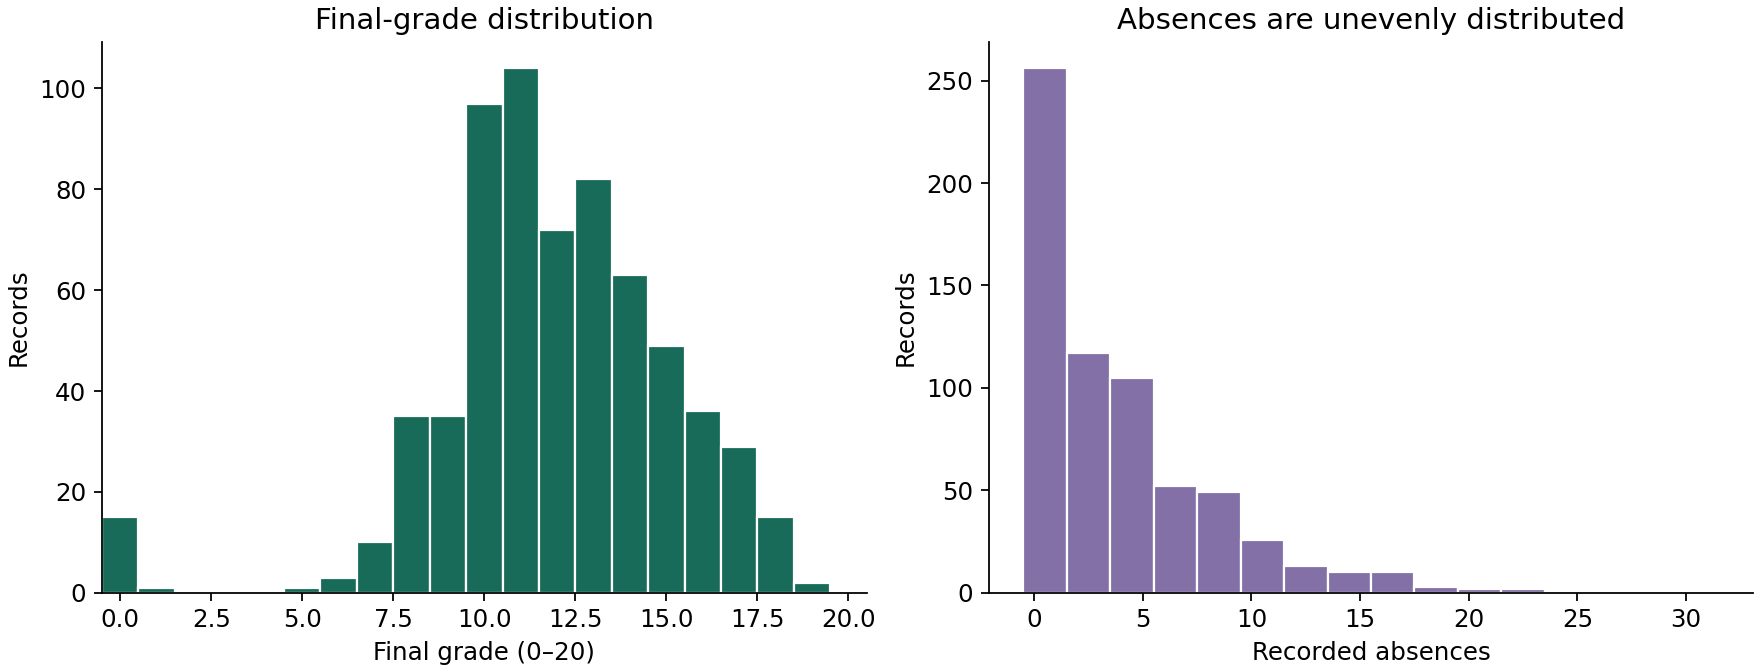

In [5]:
display(Image(filename='results/distributions.png'))

## 5. Compare groups, including uncertainty
Study time is an **ordered category**, not an exact number of hours. Show group size and grade distribution summaries alongside means.

The intervals below are 95% percentile intervals from 2,000 row-bootstrap resamples per group. They assume exchangeable records within groups and do not account for school-level clustering. They should not be read as national population estimates.

   studytime    n  mean_grade  median_grade     ci_low    ci_high
0          1  212   10.844340          11.0  10.405660  11.283019
1          2  305   12.091803          12.0  11.718033  12.465656
2          3   97   13.226804          13.0  12.773196  13.752577
3          4   35   13.057143          13.0  12.085714  14.028571

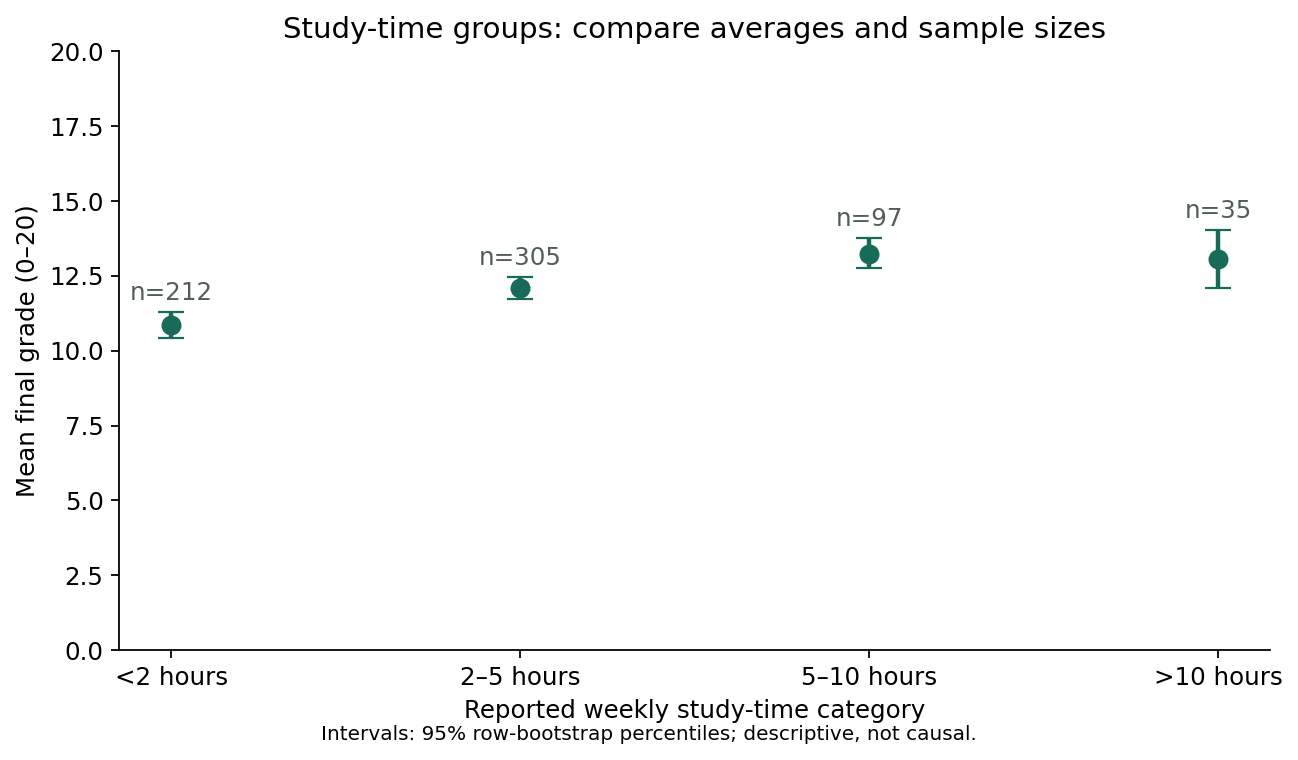

  school  studytime    n  mean_grade  median_grade     ci_low    ci_high
0     GP          1  119   11.529412          11.0  11.008403  12.025210
1     GP          2  206   12.733010          13.0  12.407646  13.058252
2     GP          3   71   13.563380          14.0  13.028169  14.084507
3     GP          4   27   13.407407          13.0  12.332407  14.445370
4     MS          1   93    9.967742          10.0   9.204301  10.666667
5     MS          2   99   10.757576          11.0   9.939394  11.545707
6     MS          3   26   12.307692          12.0  11.153846  13.461538
7     MS          4    8   11.875000          12.0   9.500000  14.250000

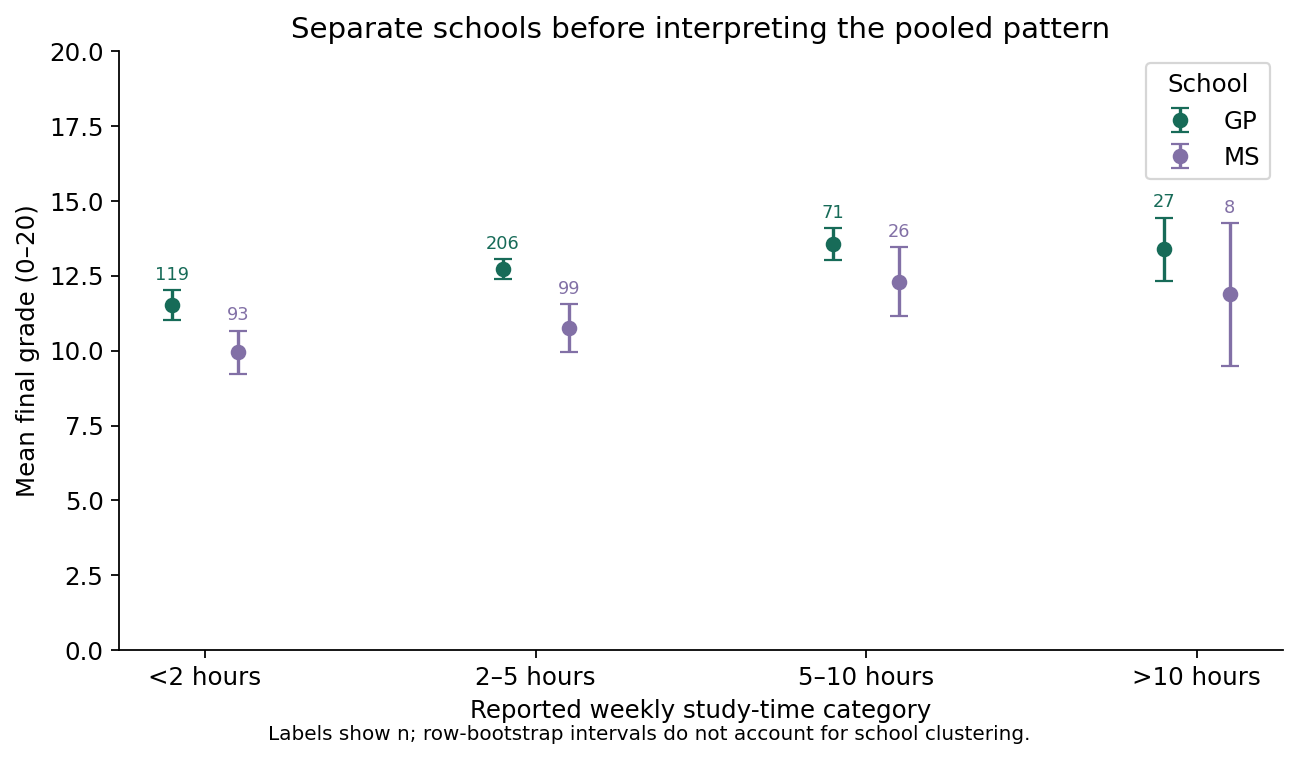

In [6]:
display(result['groups'])
display(Image(filename='results/studytime_grades.png'))
display(result['school_groups'])
display(Image(filename='results/school_comparison.png'))

## 6. SQL cross-check
.

In [7]:
display(sql_summary(result['data']))
display(sql_summary(result['data'], school='GP'))
np.testing.assert_allclose(result['sql'].mean_grade, result['groups'].mean_grade)
print('SQL and Pandas means agree.')

SQL and Pandas means agree.


   studytime study_label    n  mean_grade  mean_absences
0          1    <2 hours  212   10.844340       4.339623
1          2   2–5 hours  305   12.091803       3.600000
2          3  5–10 hours   97   13.226804       2.618557
3          4   >10 hours   35   13.057143       2.942857

   studytime study_label    n  mean_grade  mean_absences
0          1    <2 hours  119   11.529412       5.529412
1          2   2–5 hours  206   12.733010       4.092233
2          3  5–10 hours   71   13.563380       2.746479
3          4   >10 hours   27   13.407407       3.222222

## 7. Relationships and sensitivity
Spearman correlation measures ranked association. It fits ordinal study-time categories without pretending the codes are equally spaced hours. It does not establish causation.

G2 is a previous-period grade. A strong relationship with G3 would not justify calling it a before-course predictor. Removing zero final grades here is an explicit sensitivity check, not a claim that zero means missing.

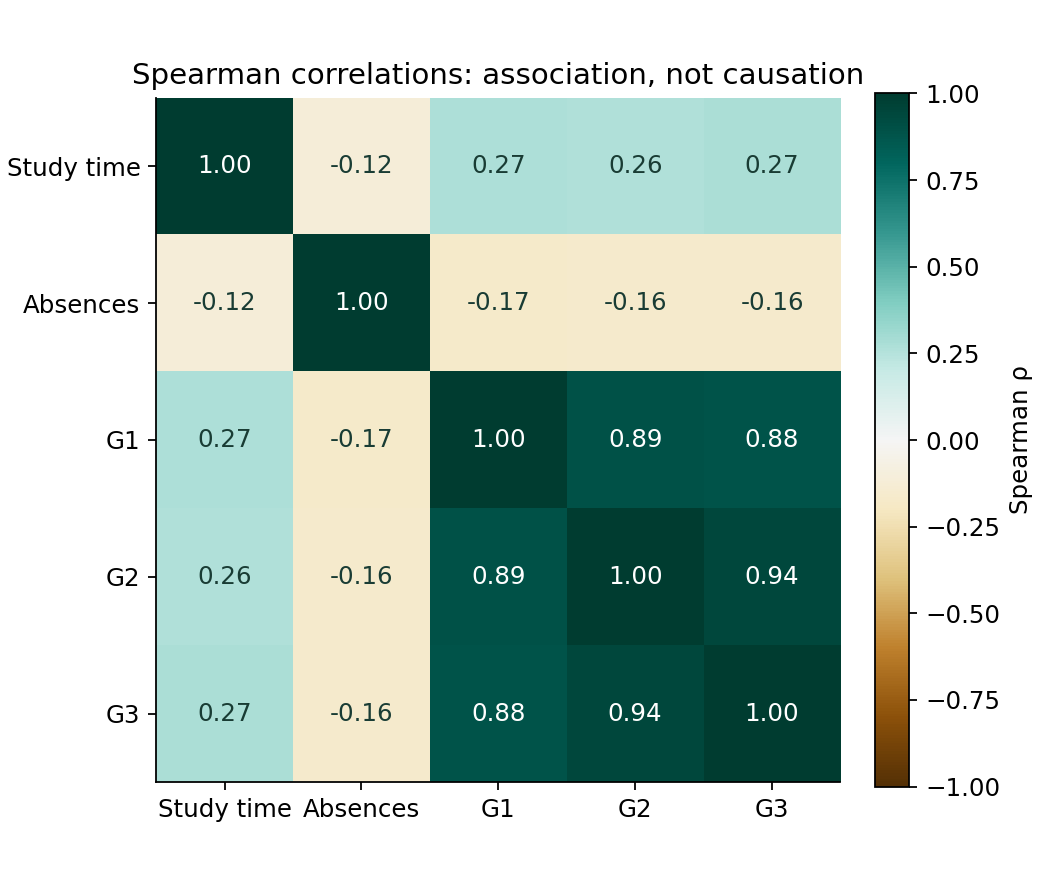

                    sample    n  studytime_G3_spearman  absences_G3_spearman
0      All recorded grades  649               0.274712             -0.158510
1  G3 > 0 sensitivity only  634               0.263635             -0.214086

{'rows': 649,
 'schools': 2,
 'mean_final_grade': 11.906009244992296,
 'median_final_grade': 12.0,
 'studytime_grade_spearman': 0.27471184833560996,
 'absences_grade_spearman': -0.15851002809372583,
 'prior_grade_G2_G3_spearman': 0.9444511866922519,
 'seed': 42,
 'bootstrap_repetitions_per_group': 2000,
 'input_sha256': 'a7594a11d7771c0efe1a740824e0e833da9c4cad07c39a9766a874575563fb3f',
 'python': '3.12.14',
 'pandas': '2.2.3',
 'numpy': '2.3.5'}

In [8]:
display(Image(filename='results/correlations.png'))
display(result['sensitivity'])
display(result['summary'])

## 8. Interpretation
The higher study-time categories generally have higher mean grades than the lowest category in this sample, but the highest category does not have the highest mean. The >10-hour category has only 35 records.

ما نقدر نقول إن عدد ساعات معين يضمن درجة أعلى هذه بيانات رصدية من مدرستين وممكن تختلف المجموعات ف عوامل أخرى 

The full report is saved to `results/report.html`, with charts embedded so it opens offline. `results/FINDINGS.md` provides a compact, reproducible written summary.


Reference for the skills : [Python Institute PCAD syllabus](https://pythoninstitute.org/pcad-exam-syllabus).